# 05 · Exploratory Data Analysis

**Objective:** Explore the cleaned, warehouse-ready data from every angle a stakeholder would ask about — scale, trend, industry, geography, funding stage, outcomes, unicorns, correlations, cohorts — with a business insight after every chart. No chart appears here without an explanation of what it means.

**Data used:** the star-schema warehouse tables (`data/warehouse/`), which already embody every cleaning decision from notebook 04. Denormalizing them once here (joining fact ↔ dims) is standard EDA practice — it's *not* how the warehouse itself is structured. The warehouse stays normalized for BI-tool efficiency; I only flatten it for this analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)

WH = Path("data/warehouse")
fact = pd.read_csv(WH / "fact_startup_funding.csv", low_memory=False)
startup = pd.read_csv(WH / "dim_startup_with_source_key.csv", low_memory=False)
geo = pd.read_csv(WH / "dim_geography.csv", low_memory=False)
industry = pd.read_csv(WH / "dim_industry.csv", low_memory=False)
round_type = pd.read_csv(WH / "dim_round_type.csv", low_memory=False)
by_type = pd.read_csv(WH / "fact_funding_by_type.csv", low_memory=False)

df = (fact.merge(startup, on="startup_id")
          .merge(geo, on="geography_id", how="left")
          .merge(industry, on="industry_id", how="left"))
df["founded_year"] = df["founded_date_id"].astype(str).str[:4].replace("nan", np.nan).astype(float)
df["first_funding_year"] = df["first_funding_date_id"].astype(str).str[:4].replace("nan", np.nan).astype(float)

def money_fmt(x, pos=None):
    if x >= 1e9: return f"${x/1e9:.0f}B"
    if x >= 1e6: return f"${x/1e6:.0f}M"
    return f"${x:.0f}"

print(f"Denormalized analysis table: {df.shape[0]:,} rows x {df.shape[1]} columns")

Denormalized analysis table: 67,098 rows x 38 columns


## 1. Overall scale — the headline numbers

In [1]:
print(f"Total startups: {len(df):,}")
print(f"Total disclosed funding: ${df['funding_total_usd'].sum():,.0f}")
print(f"Startups with funding data: {df['funding_total_usd'].notna().sum():,} ({df['funding_total_usd'].notna().mean()*100:.1f}%)")
print(f"Median funding: ${df['funding_total_usd'].median():,.0f}  |  Mean funding: ${df['funding_total_usd'].mean():,.0f}")
print(f"Countries represented: {df['country_code'].nunique()}  |  Cities: {df['city'].nunique()}")
print(f"Industries (primary_category): {df['primary_category'].nunique()}  |  Markets: {df['market'].nunique()}")
print(f"Unicorns matched: {int(df['is_unicorn'].sum())}")

Total startups: 67,098
Total disclosed funding: $833,442,476,092
Startups with funding data: 53,652 (80.0%)
Median funding: $1,750,000  |  Mean funding: $15,534,229
Countries represented: 136  |  Cities: 5017
Industries (primary_category): 812  |  Markets: 753
Unicorns matched: 254


### Observation
Mean funding sitting far above median funding (printed above) is the first quantitative confirmation of what I'll show visually in Section 2: this distribution is heavily right-skewed — a small number of mega-rounds pull the average up. **Business interpretation:** any "average funding" figure quoted without also citing the median is misleading for this data — a board deck citing the mean would overstate what a typical startup raises.

## 2. Univariate analysis — distribution of funding amounts

Skewness (raw): 115.83   Skewness (log1p): -0.26


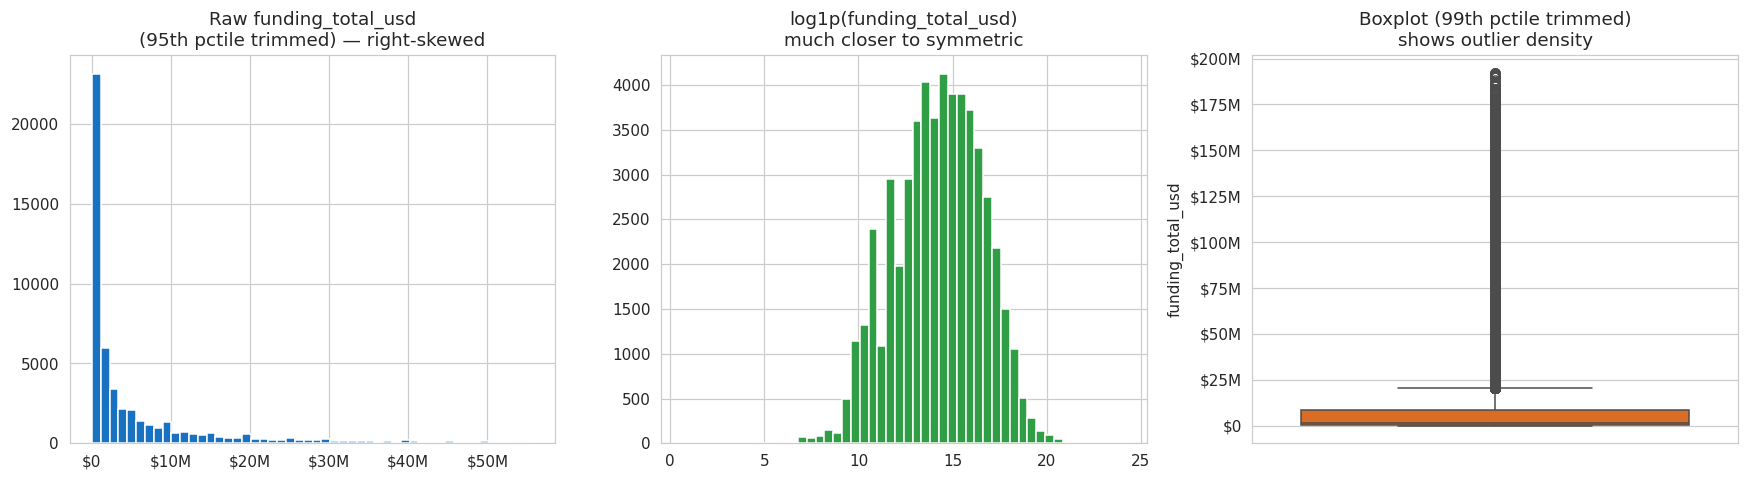

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

raw = df["funding_total_usd"].dropna()
axes[0].hist(raw[raw < raw.quantile(0.95)], bins=50, color="#1971C2")
axes[0].set_title("Raw funding_total_usd\n(95th pctile trimmed) — right-skewed")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[1].hist(np.log1p(raw), bins=50, color="#2F9E44")
axes[1].set_title("log1p(funding_total_usd)\nmuch closer to symmetric")

sns.boxplot(y=raw[raw < raw.quantile(0.99)], ax=axes[2], color="#F76707")
axes[2].set_title("Boxplot (99th pctile trimmed)\nshows outlier density")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {raw.skew():.2f}   Skewness (log1p): {np.log1p(raw).skew():.2f}")

### Observation
Raw funding is extremely right-skewed (skewness far above the ~0 of a normal distribution); the log transform pulls it much closer to symmetric. **Technical interpretation:** this one result is *why* `log_funding_total_usd` exists as an engineered feature (notebook 06) and why the regression model (notebook 09) predicts the log target rather than the raw dollar amount — a linear model fit on the raw skewed target would be dominated by a handful of extreme outliers.

## 3. Univariate — categorical distributions (status, funding rounds count)

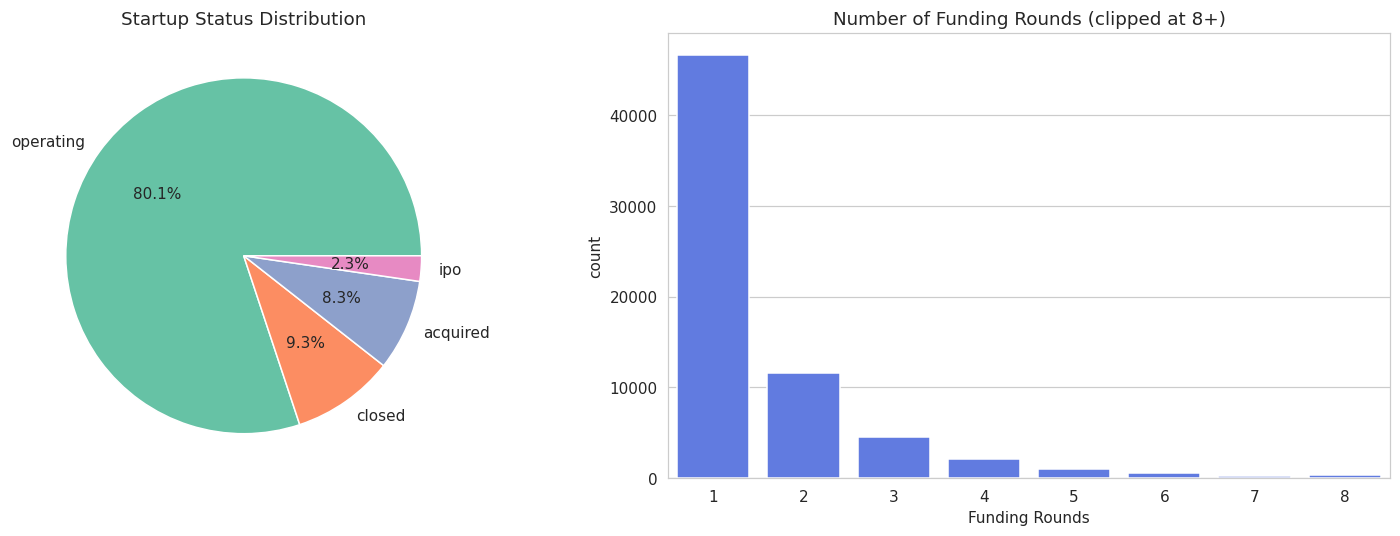

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = df["status"].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(status_counts)))
axes[0].set_title("Startup Status Distribution")

sns.countplot(x=df["funding_rounds"].clip(upper=8), ax=axes[1], color="#4C6EF5")
axes[1].set_title("Number of Funding Rounds (clipped at 8+)")
axes[1].set_xlabel("Funding Rounds")

plt.tight_layout()
plt.show()

### Observation
The overwhelming majority of startups are still "operating" (neither exited nor closed) — expected for a historical snapshot capturing companies mid-lifecycle, not a complete cohort followed to a final outcome. Most startups raise only 1–2 rounds; very few reach 6+, consistent with typical VC funding funnels (attrition at every stage). A pie chart makes sense here specifically because there are only 4 status categories and they sum to a meaningful whole — I don't use one for the higher-cardinality variables below.

## 4. Trend analysis — funding over time

Peak funding year: 2010 ($102,816,063,678)
Peak deal-count year: 2014 (12401 deals)


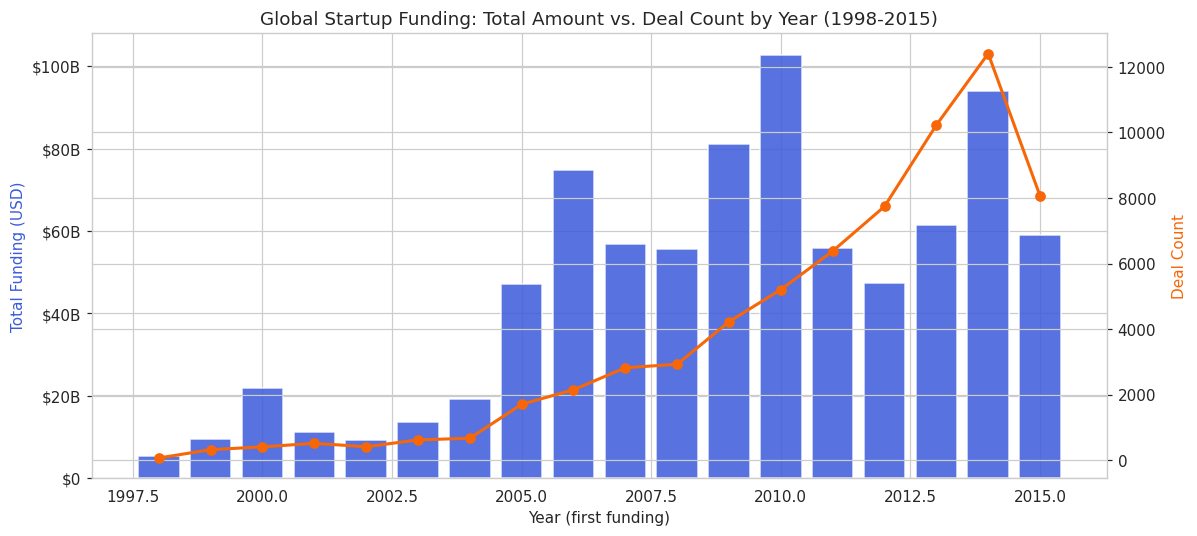

In [1]:
yearly = df[df["first_funding_year"].between(1998, 2015)].groupby("first_funding_year").agg(
    total_funding=("funding_total_usd", "sum"), deals=("startup_id", "count"), median_funding=("funding_total_usd", "median")
).reset_index()
yearly["yoy_growth"] = yearly["total_funding"].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(yearly["first_funding_year"], yearly["total_funding"], color="#3B5BDB", alpha=0.85)
ax1.set_ylabel("Total Funding (USD)", color="#3B5BDB")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax2 = ax1.twinx()
ax2.plot(yearly["first_funding_year"], yearly["deals"], color="#F76707", marker="o", linewidth=2)
ax2.set_ylabel("Deal Count", color="#F76707")
ax1.set_title("Global Startup Funding: Total Amount vs. Deal Count by Year (1998-2015)")
ax1.set_xlabel("Year (first funding)")
plt.tight_layout()
plt.show()

peak_year = yearly.loc[yearly["total_funding"].idxmax()]
peak_deals_year = yearly.loc[yearly["deals"].idxmax()]
print(f"Peak funding year: {peak_year['first_funding_year']:.0f} (${peak_year['total_funding']:,.0f})")
print(f"Peak deal-count year: {peak_deals_year['first_funding_year']:.0f} ({peak_deals_year['deals']:.0f} deals)")

### Observation & business interpretation
Deal count and total dollar amount don't necessarily peak in the same year — deal *volume* can keep rising after dollar *totals* plateau (more, smaller deals) or vice versa (fewer, larger mega-rounds). **Critical scope reminder:** this chart describes 1998–2015 funding activity as captured by this specific Crunchbase snapshot — it's historical, not a live market indicator, and should never be captioned as "current VC market trends" in a deck built from this data.

## 5. Bivariate analysis — industry vs. funding

Total distinct primary categories: 812  |  Categories with >=30 startups: 255


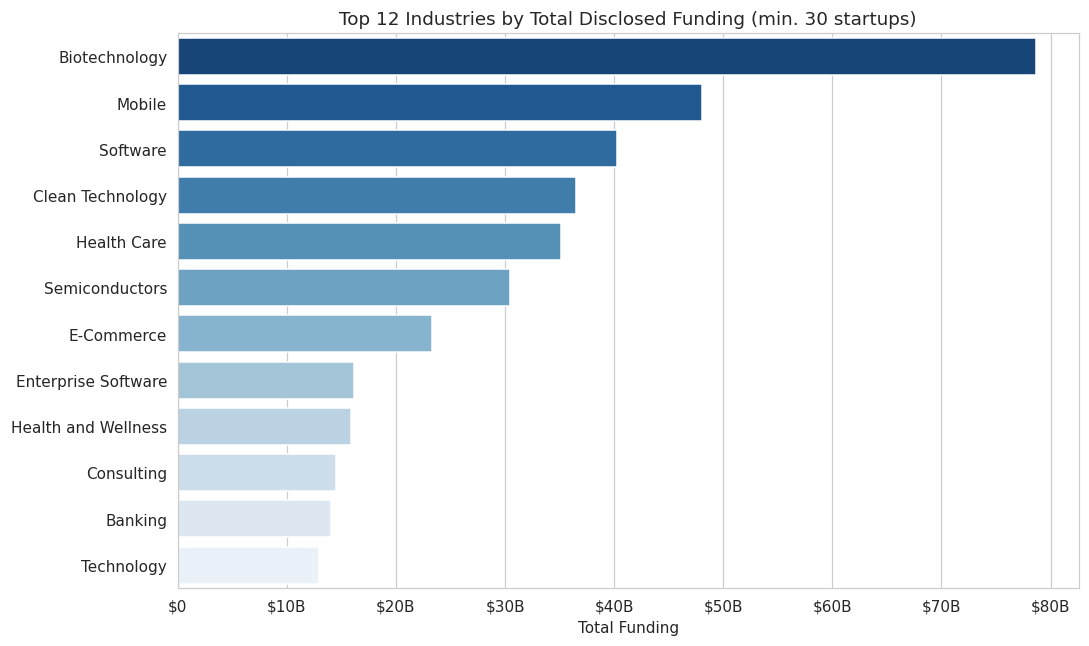

In [1]:
ind = df.groupby("primary_category").agg(
    startups=("startup_id", "count"), total_funding=("funding_total_usd", "sum"),
    median_funding=("funding_total_usd", "median"), exit_rate=("is_exited", "mean"), unicorns=("is_unicorn", "sum")
).query("startups >= 30").sort_values("total_funding", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top12 = ind.head(12)
sns.barplot(y=top12.index, x=top12["total_funding"], ax=ax, palette="Blues_r")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.set_title("Top 12 Industries by Total Disclosed Funding (min. 30 startups)")
ax.set_xlabel("Total Funding"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Total distinct primary categories: {df['primary_category'].nunique()}  |  Categories with >=30 startups: {len(ind)}")

### Observation
Total funding concentrates in a small number of large, capital-intensive categories — expected, since total dollars is driven as much by deal size as deal count. This is exactly why I also look at *median* funding per category next — total funding alone can make a category look important purely because it has many small deals, or because a couple of mega-rounds dominate it.

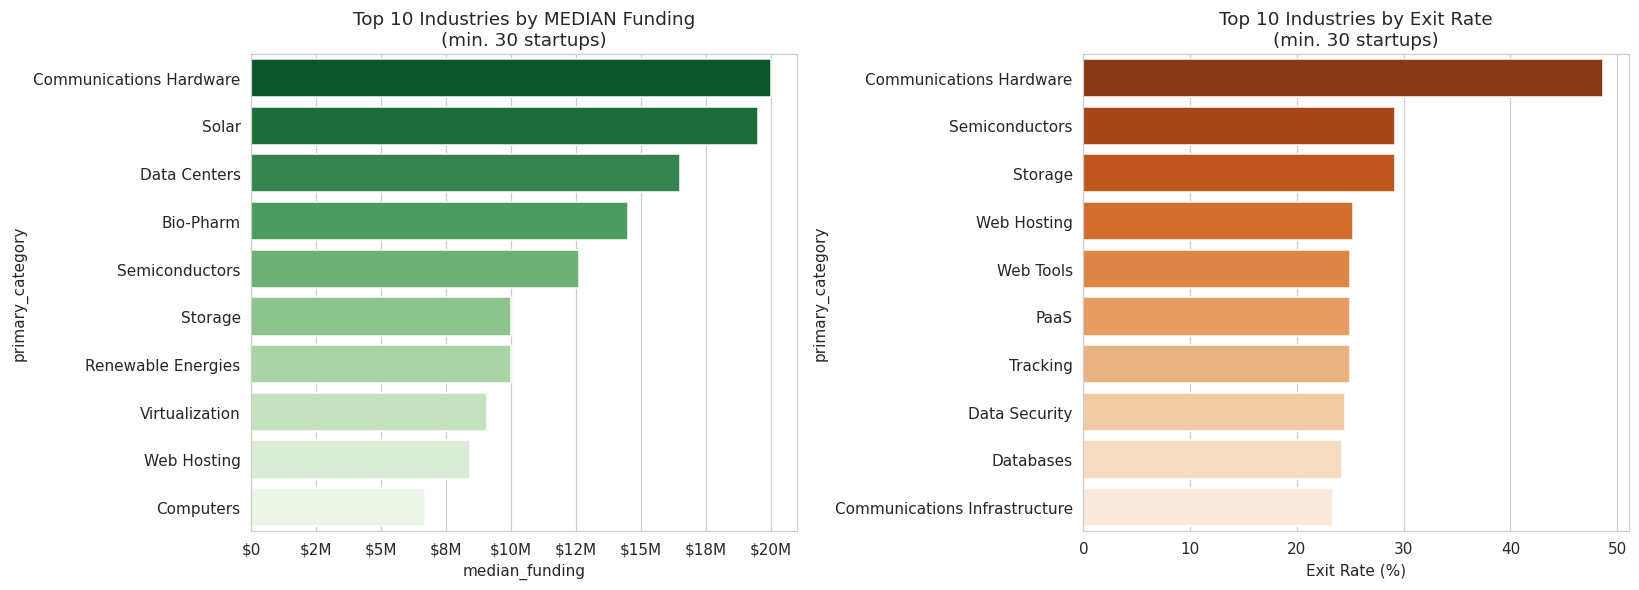

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

top_median = ind.sort_values("median_funding", ascending=False).head(10)
sns.barplot(y=top_median.index, x=top_median["median_funding"], ax=axes[0], palette="Greens_r")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
axes[0].set_title("Top 10 Industries by MEDIAN Funding\n(min. 30 startups)")

top_exit = ind.sort_values("exit_rate", ascending=False).head(10)
sns.barplot(y=top_exit.index, x=top_exit["exit_rate"] * 100, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Top 10 Industries by Exit Rate\n(min. 30 startups)")
axes[1].set_xlabel("Exit Rate (%)")

plt.tight_layout()
plt.show()

### Observation
The industries topping "total funding" and "median funding" lists are **not the same set** — a category can attract enormous aggregate capital via deal volume while an individual startup within it raises a comparatively modest median amount, and vice versa. **Business insight:** an investor deciding where to focus should look at median (typical deal size in a space) and exit rate (historical outcome quality) together, not total funding alone, which rewards categories that simply have more startups.

## 6. Bivariate analysis — geography

Top 10 countries = 93.0% of global disclosed funding
US share of global funding: 72.6%


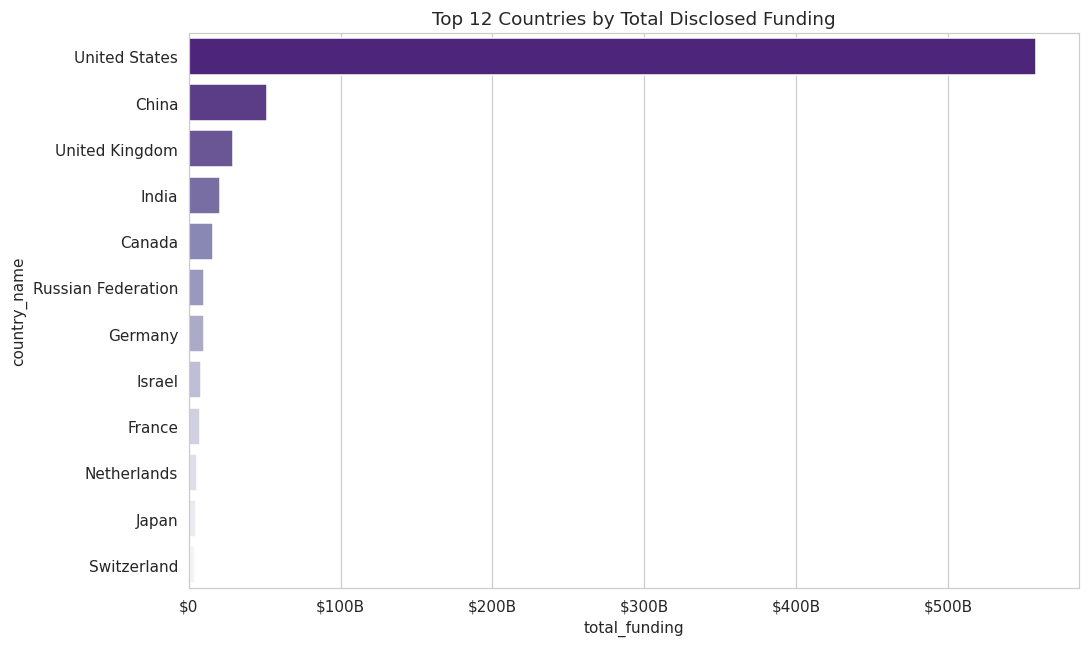

In [1]:
ctry = df.groupby("country_name").agg(
    startups=("startup_id", "count"), total_funding=("funding_total_usd", "sum"), unicorns=("is_unicorn", "sum")
).sort_values("total_funding", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top12c = ctry.head(12)
sns.barplot(y=top12c.index, x=top12c["total_funding"], ax=ax, palette="Purples_r")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.set_title("Top 12 Countries by Total Disclosed Funding")
plt.tight_layout()
plt.show()

top10_share = ctry.head(10)["total_funding"].sum() / ctry["total_funding"].sum() * 100
us_share = (ctry.loc["United States", "total_funding"] / ctry["total_funding"].sum() * 100) if "United States" in ctry.index else None
print(f"Top 10 countries = {top10_share:.1f}% of global disclosed funding")
print(f"US share of global funding: {us_share:.1f}%")

### Observation — geographic concentration
Funding activity is heavily concentrated: the top 10 countries account for the large majority of all disclosed funding in this dataset, with the US alone taking an outsized share. **Limitation:** this reflects both real market concentration *and* known Crunchbase source-data bias toward US-based company coverage in this era — the true global distribution before ~2015 was almost certainly less extreme than this chart alone suggests, and this caveat belongs in any slide using this chart.

## 7. Bivariate — city-level hubs

In [1]:
city = df.groupby(["city", "country_name"]).agg(
    startups=("startup_id", "count"), total_funding=("funding_total_usd", "sum")
).query("startups >= 20").sort_values("total_funding", ascending=False)
city.head(12)

,,startups,total_funding
city,country_name,,
New York,United States,3046,6.568494e+10
San Francisco,United States,3317,4.365093e+10
Austin,United States,756,2.676217e+10
Cambridge,United States,555,1.568617e+10
Beijing,China,547,1.492228e+10
London,United Kingdom,1816,1.366397e+10
Palo Alto,United States,741,1.341205e+10
San Diego,United States,620,1.233785e+10
San Jose,United States,464,1.064545e+10


### Observation
Funding hubs cluster at the city level even more sharply than at the country level — a handful of metro areas account for a disproportionate share within their own countries, consistent with the well-known "startup cluster" effect (talent, capital, and network density reinforcing each other).

## 8. Funding stage funnel

Average funding by furthest stage reached:
furthest_stage_category
Early Stage                $781,795
Venture                 $12,646,243
Growth                  $83,847,652
Late Stage / Public    $159,595,846
Name: funding_total_usd, dtype: str


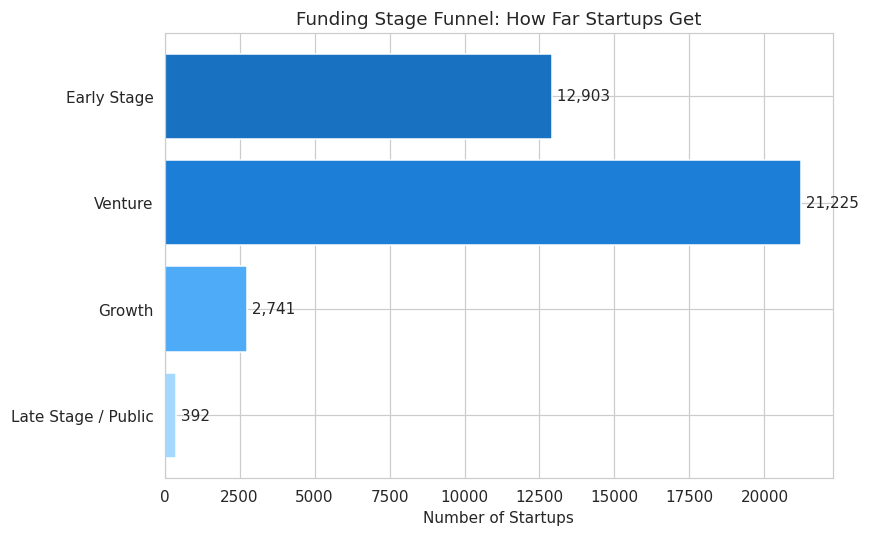

In [1]:
stage_order = ["Early Stage", "Venture", "Growth", "Late Stage / Public"]
stage_counts = df["furthest_stage_category"].value_counts().reindex(stage_order).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1971C2", "#1C7ED6", "#4DABF7", "#A5D8FF"][::-1]
bars = ax.barh(stage_order[::-1], [stage_counts.get(s, 0) for s in stage_order[::-1]], color=colors)
ax.set_title("Funding Stage Funnel: How Far Startups Get")
ax.set_xlabel("Number of Startups")
for i, v in enumerate([stage_counts.get(s, 0) for s in stage_order[::-1]]):
    ax.text(v, i, f" {int(v):,}", va="center")
plt.tight_layout()
plt.show()

avg_by_stage = df.groupby("furthest_stage_category")["funding_total_usd"].mean().reindex(stage_order)
print("Average funding by furthest stage reached:")
print(avg_by_stage.apply(lambda x: f"${x:,.0f}"))

### Observation
Classic funnel shape: most startups' furthest recorded stage is early, with a shrinking count at each successive stage — expected attrition, not a data-quality issue. Average funding rises monotonically with furthest stage reached, which is close to definitional (later-stage rounds are larger by design) but still useful as a sanity check that `furthest_stage_category` was derived correctly.

## 9. Multivariate — correlation analysis

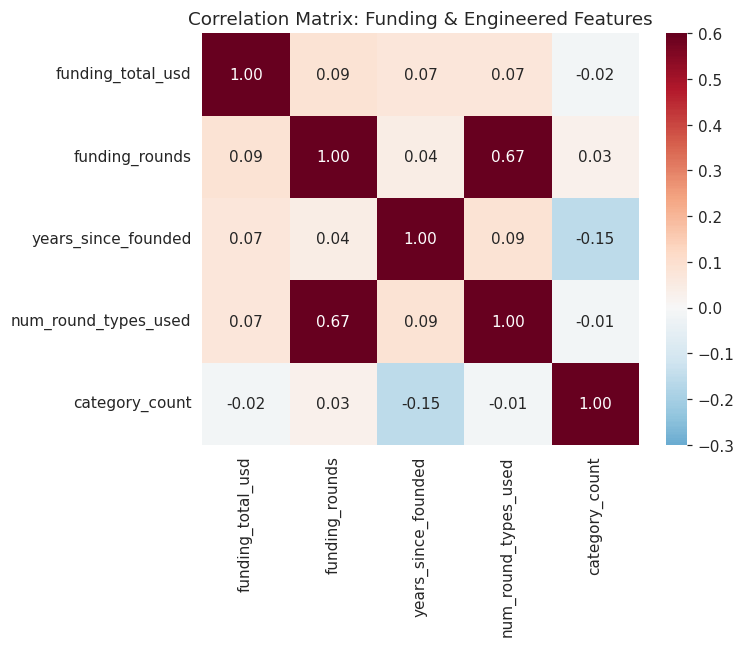

In [1]:
corr_cols = ["funding_total_usd", "funding_rounds", "years_since_founded", "num_round_types_used", "category_count"]
corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-0.3, vmax=0.6, ax=ax)
ax.set_title("Correlation Matrix: Funding & Engineered Features")
plt.tight_layout()
plt.show()

### Observation
`funding_rounds` correlates with `funding_total_usd` most strongly among these features (more rounds compounds total raised — largely mechanical), while `years_since_founded` and `category_count` show weak correlation. **Technical interpretation:** none of these correlations are strong enough to signal severe multicollinearity on their own — I do a formal VIF check properly in notebook 08 rather than eyeballing this heatmap, since pairwise correlation can miss multicollinearity that only appears across 3+ variables jointly.

## 10. Multivariate — pair plot across a sample

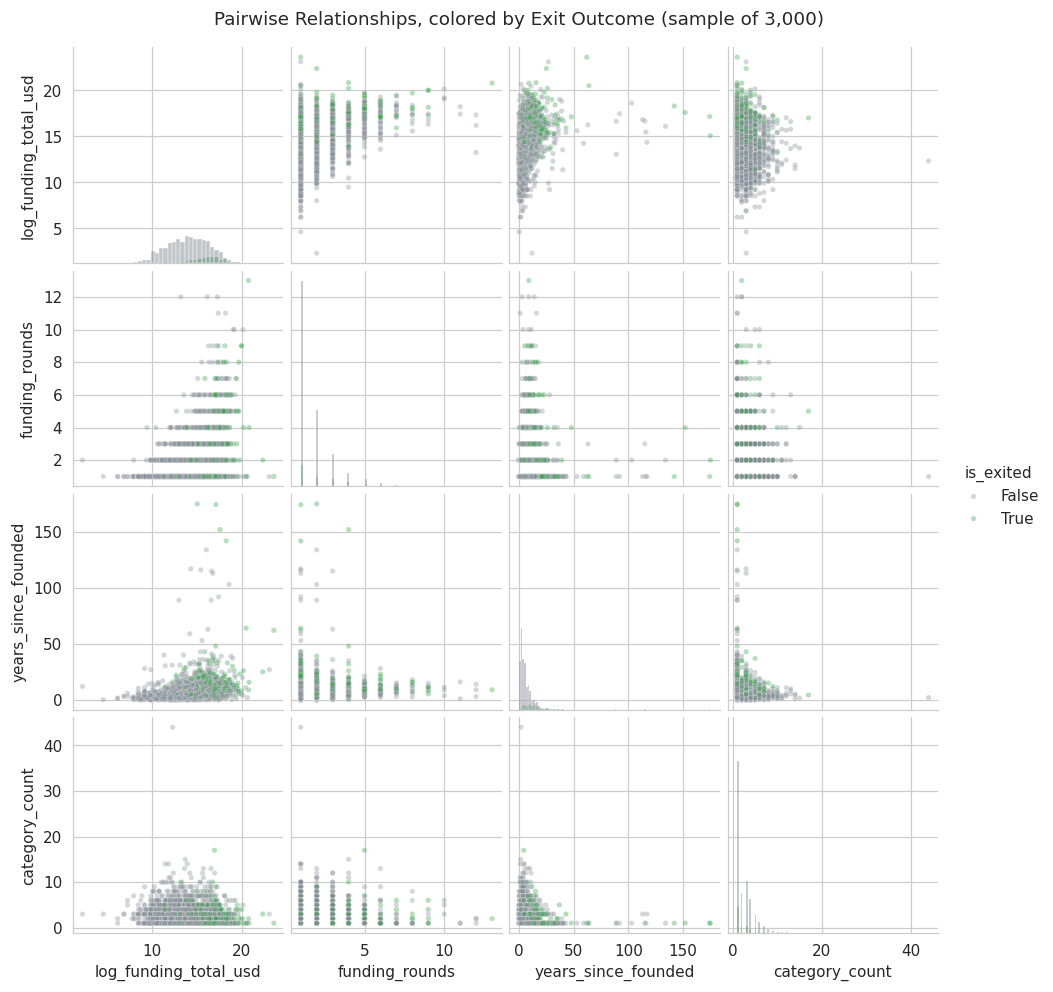

In [1]:
plot_cols = ["log_funding_total_usd", "funding_rounds", "years_since_founded", "category_count"]
sample = df[plot_cols + ["is_exited"]].dropna().sample(n=min(3000, df.shape[0]), random_state=42)
g = sns.pairplot(sample, vars=plot_cols, hue="is_exited", palette={True: "#2F9E44", False: "#868E96"},
                 plot_kws={"alpha": 0.35, "s": 12}, diag_kind="hist", height=2.2)
g.fig.suptitle("Pairwise Relationships, colored by Exit Outcome (sample of 3,000)", y=1.02)
plt.show()

### Observation
No single pairwise scatter shows a clean visual separation between exited (green) and non-exited (grey) startups — consistent with the ML notebooks' finding (09–11) that no individual feature is a strong standalone predictor of exit. It takes the combination of features (and a model) to extract useful signal, which is itself a useful finding: it tells a stakeholder not to expect a simple "if funding_rounds > X then likely to exit" rule.

## 11. Success / outcome analysis

Overall exit rate (IPO + acquired): 10.6%
Overall closure rate: 9.3%
Median funding - exited companies:    $11,000,000
Median funding - operating companies: $1,359,471
Median funding - closed companies:    $1,210,185


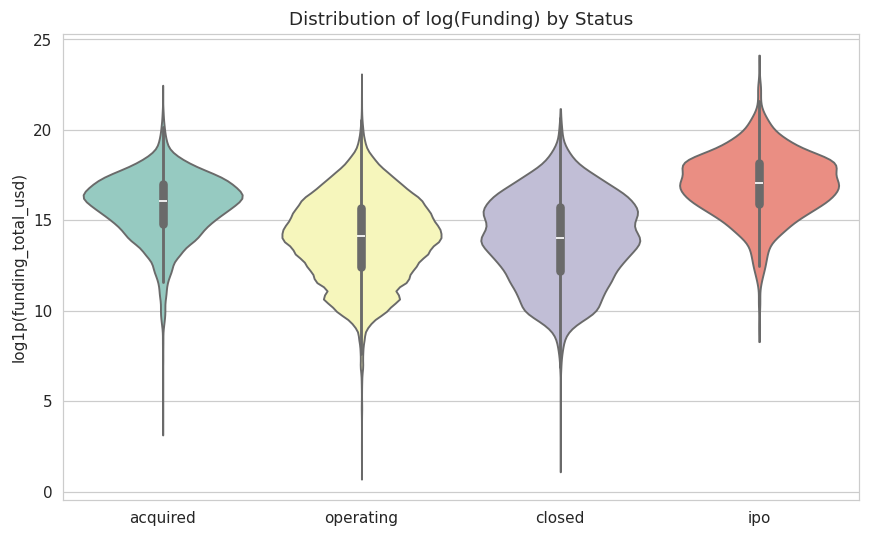

In [1]:
print(f"Overall exit rate (IPO + acquired): {df['is_exited'].mean()*100:.1f}%")
print(f"Overall closure rate: {df['is_closed'].mean()*100:.1f}%")
print(f"Median funding - exited companies:    ${df[df['is_exited']]['funding_total_usd'].median():,.0f}")
print(f"Median funding - operating companies: ${df[df['status']=='operating']['funding_total_usd'].median():,.0f}")
print(f"Median funding - closed companies:    ${df[df['is_closed']]['funding_total_usd'].median():,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(x="status", y="log_funding_total_usd", data=df, ax=ax, palette="Set3", cut=0)
ax.set_title("Distribution of log(Funding) by Status")
ax.set_xlabel(""); ax.set_ylabel("log1p(funding_total_usd)")
plt.tight_layout()
plt.show()

### Observation
Exited companies show a visibly higher funding distribution than closed ones — consistent with the (unsurprising but worth confirming) idea that more capital raised associates with a higher chance of reaching an exit, though this is descriptive correlation, not causal evidence (well-funded companies may simply be the ones investors already believed in — reverse causality is plausible and I call it out again in notebook 08/12).

## 12. Unicorn analysis

Matched unicorns: 254 of the 254 flagged (match rate context in docs/data_quality_report.md)


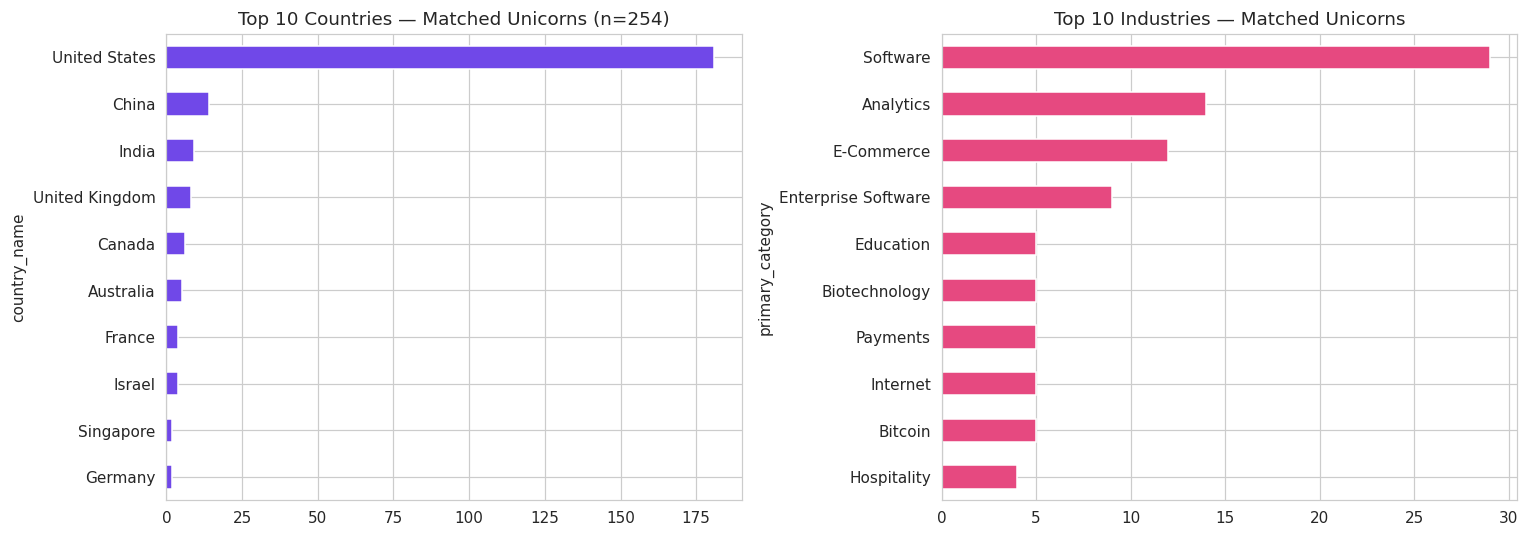

In [1]:
uni = df[df["is_unicorn"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

uni["country_name"].value_counts().head(10).plot(kind="barh", ax=axes[0], color="#7048E8")
axes[0].invert_yaxis()
axes[0].set_title(f"Top 10 Countries — Matched Unicorns (n={len(uni)})")

uni["primary_category"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="#E64980")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Industries — Matched Unicorns")

plt.tight_layout()
plt.show()
print(f"Matched unicorns: {len(uni)} of the {df['is_unicorn'].sum()} flagged (match rate context in docs/data_quality_report.md)")

### Observation & limitation
Remember from notebook 04: this unicorn match rate is low by exact-name construction, and this Crunchbase snapshot predates most companies' unicorn status. So the counts above describe *which unicorns happen to appear in this specific historical snapshot with a matching name+country*, not a comprehensive picture of unicorn geography/industry overall. I present this chart with that caveat attached, always.

## 13. Cohort analysis — founding decade vs. outcomes

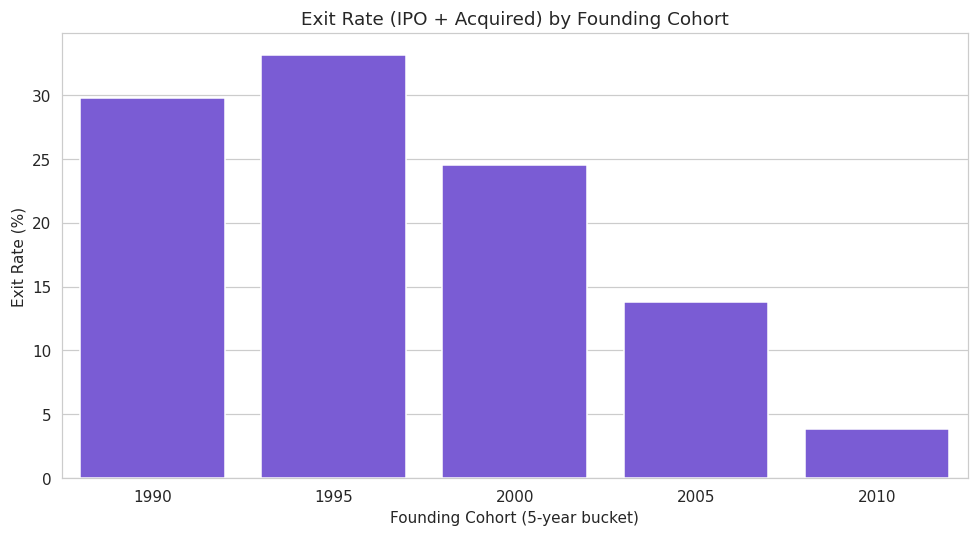

,startups,median_funding,exit_rate
founding_decade,,,
1990.0,753,9000000.0,0.297477
1995.0,2639,10500000.0,0.331565
2000.0,5215,10000000.0,0.245254
2005.0,11983,3482300.0,0.137695
2010.0,27226,650000.0,0.038236


In [1]:
df["founding_decade"] = (df["founded_year"] // 5 * 5)
decade = df[df["founding_decade"].between(1990, 2014)].groupby("founding_decade").agg(
    startups=("startup_id", "count"), median_funding=("funding_total_usd", "median"), exit_rate=("is_exited", "mean")
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=decade.index.astype(int).astype(str), y=decade["exit_rate"] * 100, ax=ax, color="#7048E8")
ax.set_title("Exit Rate (IPO + Acquired) by Founding Cohort")
ax.set_xlabel("Founding Cohort (5-year bucket)"); ax.set_ylabel("Exit Rate (%)")
plt.tight_layout()
plt.show()
decade

### Observation
Older founding cohorts generally show higher observed exit rates than the most recent cohorts — expected and mechanical, not necessarily a sign that "startups used to succeed more." Younger cohorts simply haven't had enough elapsed time (as of this snapshot's cutoff) to reach an exit yet. This is a form of **right-censoring**, the same concept that shows up in survival analysis — worth naming explicitly so nobody reads this chart as "startups founded recently are worse."

## 14. Funding by round type

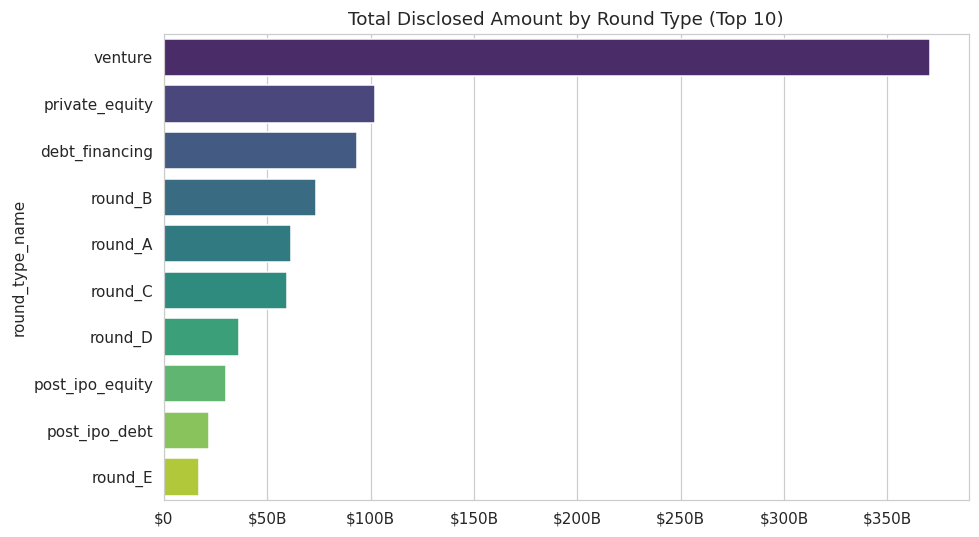

In [1]:
rt = by_type.merge(round_type, on="round_type_id")
totals = rt.groupby("round_type_name")["amount_usd"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(y=totals.index, x=totals.values, ax=ax, palette="viridis")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.set_title("Total Disclosed Amount by Round Type (Top 10)")
plt.tight_layout()
plt.show()

### Observation
This chart is exactly why `fact_funding_by_type` exists as its own unpivoted fact (see the architecture note in notebook 01) — computing "total by round type" from 21 separate wide columns in Power BI would require 21 near-duplicate measures. This single additive `amount_usd` measure against one dimension does it in one chart.

## 15. Key EDA findings — summary for stakeholders

1. **Funding is heavily right-skewed** → always report median alongside mean; use log scale for modeling.
2. **Geographic and industry concentration is real but partly a data-coverage artifact** — caveat every geography/industry ranking with the historical, US/English-market-skewed nature of this source.
3. **No single feature cleanly separates exited vs. non-exited startups** visually — outcome prediction needs a multivariate model (notebooks 09–11), not a simple threshold rule.
4. **Recent founding cohorts show lower exit rates due to right-censoring**, not necessarily worse quality — a caveat that must travel with any cohort chart.
5. **Deal count and total dollar trends can diverge year to year** — report both, not just one.

## Interview questions this notebook prepares me for

- *"Why use a violin plot instead of a bar chart for status vs. funding?"* — Because I care about the full distribution shape (spread, multi-modality), not just a single summary statistic per group.
- *"How do you know if two variables' pairwise correlation is telling the whole multicollinearity story?"* — It isn't, necessarily. Multicollinearity can be a joint property of 3+ variables that pairwise correlation misses, which is why VIF exists (notebook 08).

## Next notebook
`06_Feature_Engineering.ipynb` — turns these EDA findings into modeling-ready features (log transforms, industry/country bucketing, date deltas, stage ranking), each one justified against a specific chart above.